In [2]:
from unicodedata import category

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
print("initialisation des library")

initialisation des library


In [4]:
data = "./data/Superstore.csv"
store_data = pd.read_csv(data, encoding='latin1')

In [5]:
store_data.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2013-152156,09-11-2013,12-11-2013,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2013-152156,09-11-2013,12-11-2013,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2013-138688,13-06-2013,17-06-2013,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2012-108966,11-10-2012,18-10-2012,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2012-108966,11-10-2012,18-10-2012,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [26]:
store_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   str    
 2   Order Date     9994 non-null   str    
 3   Ship Date      9994 non-null   str    
 4   Ship Mode      9994 non-null   str    
 5   Customer ID    9994 non-null   str    
 6   Customer Name  9994 non-null   str    
 7   Segment        9994 non-null   str    
 8   Country        9994 non-null   str    
 9   City           9994 non-null   str    
 10  State          9994 non-null   str    
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   str    
 13  Product ID     9994 non-null   str    
 14  Category       9994 non-null   str    
 15  Sub-Category   9994 non-null   str    
 16  Product Name   9994 non-null   str    
 17  Sales          9994 non-null   float64
 18  Quantity       9994

In [27]:
store_data.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [28]:
store_data.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='str')

In [14]:
#conversion
store_data['Ship Date'] = pd.to_datetime(store_data['Ship Date'], dayfirst=True)

In [11]:
store_data['Order Date'] = pd.to_datetime(store_data['Order Date'], dayfirst=True)

In [15]:
# creation de nouvelles colonnes a partir des dates
store_data['Year'] = store_data['Ship Date'].dt.year
store_data['Month'] = store_data['Ship Date'].dt.month
store_data['Quarter'] = store_data['Ship Date'].dt.day

In [16]:
store_data.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit', 'Ship Date ',
       'Year', 'Month', 'Quarter'],
      dtype='str')

In [35]:
store_data.rename(columns={'Ship Date ':'Ship Date'}, inplace=True)
store_data.rename(columns={'ProductName ':'Product Name'}, inplace=True)

In [18]:
store_data.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit', 'Ship Date',
       'Year', 'Month', 'Quarter'],
      dtype='str')

In [19]:
# trouver la category qui genere le plsu de CA
CA = store_data.groupby('Category')['Sales'].sum()
print(CA)

Category
Furniture          741999.7953
Office Supplies    719047.0320
Technology         836154.0330
Name: Sales, dtype: float64


In [21]:
# trouver la sub-category qui est le plus vendu en quantite
SC = store_data.groupby('Sub-Category')['Quantity'].sum()
print(SC)

Sub-Category
Accessories    2976
Appliances     1729
Art            3000
Binders        5974
Bookcases       868
Chairs         2356
Copiers         234
Envelopes       906
Fasteners       914
Furnishings    3563
Labels         1400
Machines        440
Paper          5178
Phones         3289
Storage        3158
Supplies        647
Tables         1241
Name: Quantity, dtype: int64


In [22]:
# Trouver la region la plus profitable
RP = store_data.groupby('Region')['Profit'].sum()
print(RP)

Region
Central     39706.3625
East        91522.7800
South       46749.4303
West       108418.4489
Name: Profit, dtype: float64


In [29]:
# Y a-t-il des sous-catégories qui vendent beaucoup mais perdent de l'argent ?
money = store_data.groupby('Sub-Category').agg({'Quantity': 'sum', 'Profit': 'sum'})
print(money)
# sans filtrer

              Quantity      Profit
Sub-Category                      
Accessories       2976  41936.6357
Appliances        1729  18138.0054
Art               3000   6527.7870
Binders           5974  30221.7633
Bookcases          868  -3472.5560
Chairs            2356  26590.1663
Copiers            234  55617.8249
Envelopes          906   6964.1767
Fasteners          914    949.5182
Furnishings       3563  13059.1436
Labels            1400   5546.2540
Machines           440   3384.7569
Paper             5178  34053.5693
Phones            3289  44515.7306
Storage           3158  21278.8264
Supplies           647  -1189.0995
Tables            1241 -17725.4811


In [30]:
# filtrer
problem_subcat = money[
    (money['Quantity'] > money['Quantity'].mean()) &
    (money['Profit'] < 0)
]
print(problem_subcat)

Empty DataFrame
Columns: [Quantity, Profit]
Index: []


In [31]:
# Quel est l'impact des remises (`Discount`) sur le profit ?
impact = store_data[['Discount', 'Profit']].corr()
print(impact)

          Discount    Profit
Discount  1.000000 -0.219487
Profit   -0.219487  1.000000


In [37]:
# Quels sont les 10 produits les moins rentables ?
worst = store_data.groupby('Product Name')['Profit'].sum()
worst_10 = worst.sort_values().head(10)
print(worst_10)

Product Name
Cubify CubeX 3D Printer Double Head Print                           -8879.9704
Lexmark MX611dhe Monochrome Laser Printer                           -4589.9730
Cubify CubeX 3D Printer Triple Head Print                           -3839.9904
Chromcraft Bull-Nose Wood Oval Conference Tables & Bases            -2876.1156
Bush Advantage Collection Racetrack Conference Table                -1934.3976
GBC DocuBind P400 Electric Binding System                           -1878.1662
Cisco TelePresence System EX90 Videoconferencing Unit               -1811.0784
Martin Yale Chadless Opener Electric Letter Opener                  -1299.1836
Balt Solid Wood Round Tables                                        -1201.0581
BoxOffice By Design Rectangular and Half-Moon Meeting Room Tables   -1148.4375
Name: Profit, dtype: float64


Order Date
1      95365.9376
2      60172.6494
3     199252.9840
4     141851.5674
5     156122.2867
6     147082.6113
7     149580.8380
8     159589.4510
9     309770.0997
10    197115.2017
11    349120.0740
12    332177.1595
Name: Sales, dtype: float64


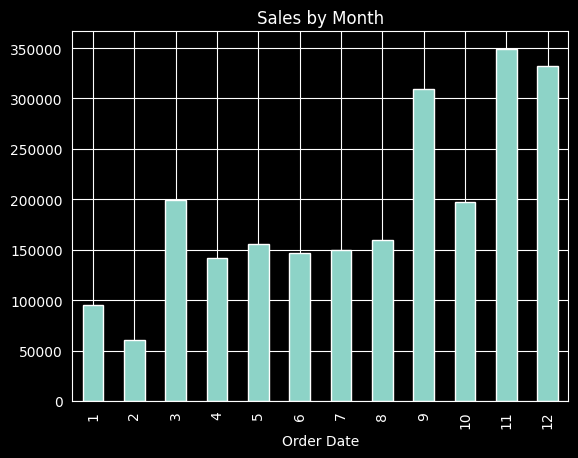

In [41]:
# Les ventes sont-elles saisonnières ? mois
sales_month = store_data.groupby(store_data['Order Date'].dt.month)['Sales'].sum()
print(sales_month)

sales_month.plot(kind='bar')
plt.title("Sales by Month")
plt.show()

Order Date
1    354791.5710
2    445056.4654
3    618940.3887
4    878412.4352
Name: Sales, dtype: float64


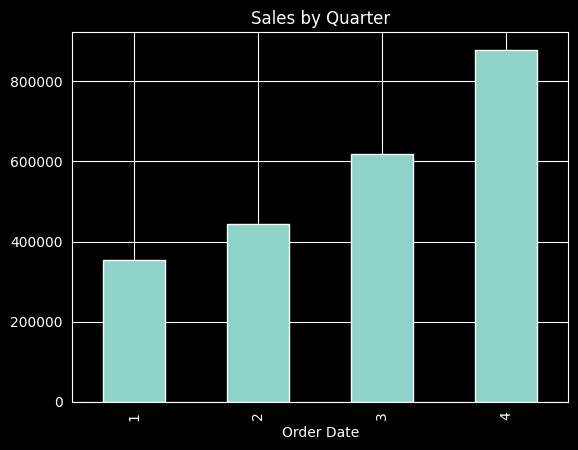

In [42]:
# Les ventes sont-elles saisonnières ? trimestre
sales_by_quarter = store_data.groupby(store_data['Order Date'].dt.quarter)['Sales'].sum()
print(sales_by_quarter)

sales_by_quarter.plot(kind='bar')
plt.title("Sales by Quarter")
plt.show()

Order Date
2011    484247.4981
2012    470532.5090
2013    608473.8300
2014    733947.0232
Name: Sales, dtype: float64


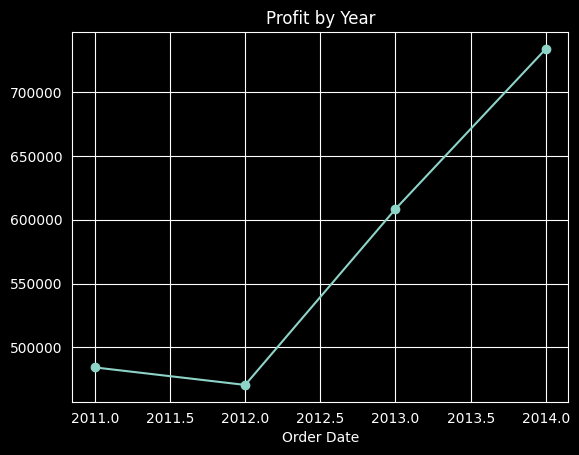

In [40]:
# Est-ce que le profit augmente d'année en année ?
profit_by_year = store_data.groupby(store_data['Order Date'].dt.year)['Sales'].sum()
print(profit_by_year)
profit_by_year.plot(kind='line', marker='o')
plt.title("Profit by Year")
plt.show()

NameError: name 'dw_1' is not defined

Visualissation

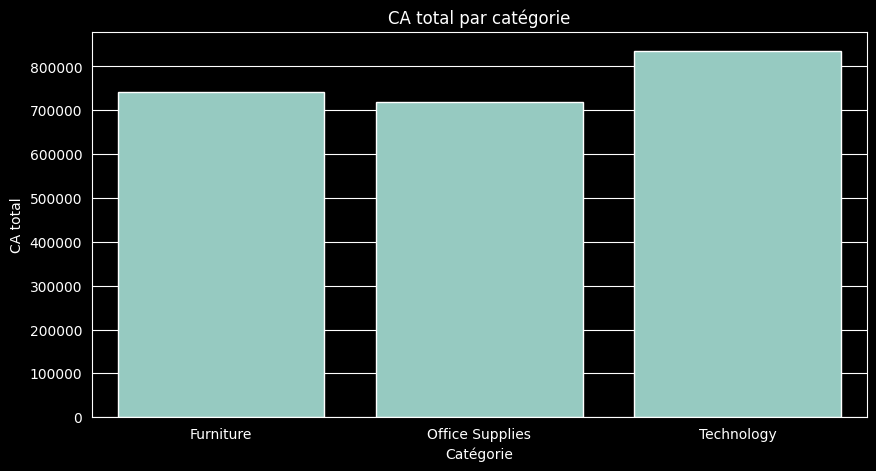

In [46]:
plt.figure(figsize=(10, 5))
sns.barplot(x=CA.index, y=CA.values)
plt.title("CA total par catégorie")
plt.xlabel("Catégorie")
plt.ylabel("CA total")
plt.show()